In [1]:
import polars as pl

In [2]:
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes.parquet -o /home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes.parquet

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes.parquet -o /home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes_EUR.parquet

Error: path
"/home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes_EUR.parquet" already
exists but -f/--overwrite was not set


In [3]:
b2p = pl.scan_parquet('/home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes_EUR.parquet')
b2p.head().collect()

CHROM,POS,REF,ALT,SAMPLE,GT
str,i64,str,str,str,i8
"""chr10""",20020006,"""C""","""T""","""5317620""",1
"""chr10""",20020007,"""TTTTCTTGC""","""T""","""5546988""",1
"""chr10""",20020010,"""T""","""C""","""2793793""",1
"""chr10""",20020014,"""G""","""A""","""1722739""",1
"""chr10""",20020014,"""G""","""A""","""1139673""",1


In [4]:
(
    b2p
    .rename({c: c.lower() for c in b2p.collect_schema().names()})
    .with_columns(
        id = pl.concat_str(
            [
                pl.col("chrom"),
                pl.lit(":"),
                pl.col("pos").cast(pl.Utf8),
                pl.lit(":"),
                pl.col("ref"),
                pl.lit(":"),
                pl.col("alt"),
            ]
        )
    )
    .select(['id'])
    .sink_parquet('/home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes_EUR_variants.parquet', engine='streaming')
)

## Get unique vars and MACs

In [1]:
import polars as pl
import matplotlib.pyplot as plt
from plotnine import *

In [2]:
var_ids = pl.scan_parquet('/home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes_EUR_variants.parquet')
var_ids.head().collect()

id
str
"""chr10:20020006:C:T"""
"""chr10:20020007:TTTTCTTGC:T"""
"""chr10:20020010:T:C"""
"""chr10:20020014:G:A"""
"""chr10:20020014:G:A"""


In [3]:
unq_vars = (
    var_ids
    .group_by('id')
    .agg(
        ac_ukb_eur = pl.len()
    )
    .sort('ac_ukb_eur')
    .collect(engine='streaming')
)

unq_vars

id,ac_ukb_eur
str,u64
"""chr10:20161710:G:A""",1
"""chr10:20167157:T:G""",1
"""chr10:20167294:T:TA""",1
"""chr10:20167314:T:C""",1
"""chr10:20167908:C:T""",1
…,…
"""chr17:674723:G:A""",377495
"""chr2:209586195:C:G""",377495
"""chr2:178820582:T:C""",377495


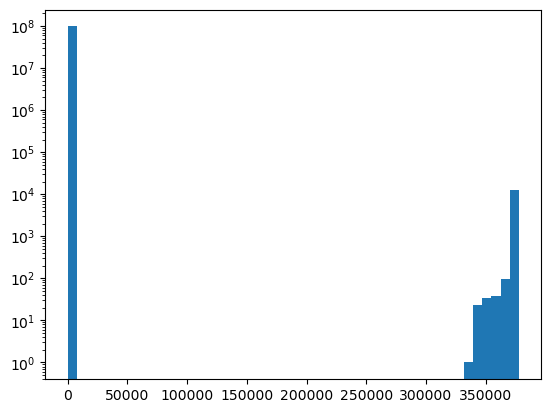

In [4]:
plt.hist(unq_vars['ac_ukb_eur'], bins=50, log=True)
plt.show()

In [5]:
max_ac = unq_vars['ac_ukb_eur'].max()
max_ac

377495

In [6]:
unq_vars = (
    unq_vars
    .with_columns(
        chrom = pl.col("id").str.split(":").list.get(0),
        pos = pl.col("id").str.split(":").list.get(1),
        ref = pl.col("id").str.split(":").list.get(2),
        alt = pl.col("id").str.split(":").list.get(3),
        mac_ukb_eur = (
            pl.when(pl.col('ac_ukb_eur') > 300_000)
            .then(max_ac + 1 - pl.col('ac_ukb_eur'))
            .otherwise(pl.col('ac_ukb_eur'))
        )
    )
)

unq_vars

id,ac_ukb_eur,chrom,pos,ref,alt,mac_ukb_eur
str,u64,str,str,str,str,u64
"""chr10:20161710:G:A""",1,"""chr10""","""20161710""","""G""","""A""",1
"""chr10:20167157:T:G""",1,"""chr10""","""20167157""","""T""","""G""",1
"""chr10:20167294:T:TA""",1,"""chr10""","""20167294""","""T""","""TA""",1
"""chr10:20167314:T:C""",1,"""chr10""","""20167314""","""T""","""C""",1
"""chr10:20167908:C:T""",1,"""chr10""","""20167908""","""C""","""T""",1
…,…,…,…,…,…,…
"""chr17:674723:G:A""",377495,"""chr17""","""674723""","""G""","""A""",1
"""chr2:209586195:C:G""",377495,"""chr2""","""209586195""","""C""","""G""",1
"""chr2:178820582:T:C""",377495,"""chr2""","""178820582""","""T""","""C""",1


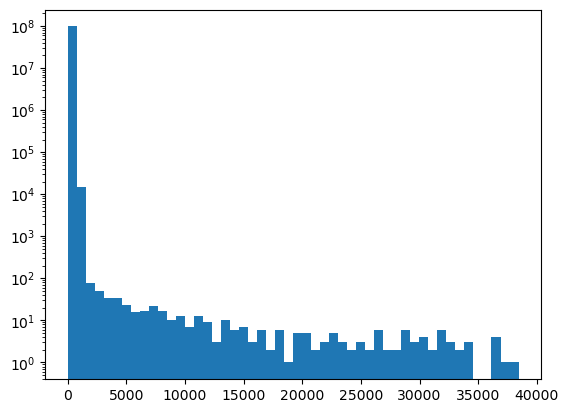

In [7]:
plt.hist(unq_vars['mac_ukb_eur'], bins=50, log=True)
plt.show()

In [8]:
unq_vars.write_parquet('/home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes_EUR_variant_metadata.parquet')

In [9]:
!dx upload /home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes_EUR_variant_metadata.parquet --path project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/

[===========================================================>] Uploaded 1,094,064,939 of 1,094,064,939 bytes (100%) /home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes_EUR_variant_metadata.parquet
ID                                file-J5Z9Z9jJg0y6fZ4v8Q0GfZ6Q
Class                             file
Project                           project-Gyp4fvjJg0yFZ374KvP9bGFJ
Folder                            /processed_data/wgs
Name                              qced_maf1e-3_loftee_olink_genes_EUR_variant_metadata.parquet
State                             closing
Visibility                        visible
Types                             -
Properties                        -
Tags                              -
Outgoing links                    -
Created                           Thu Jan 15 07:41:27 2026
Created by                        shubhankar
 via the job                      job-J5Z8f2QJg0y2GXPF66fYbzXv
Last modified                     Thu Jan 15 07:41:33 2026
Media type                